
# Bayesian Analysis

In [4]:
from preprocessing.pipeline import preprocess_all

from frequentist.models import VAR

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.var_model import VAR as smVAR
from statsmodels.graphics.tsaplots import plot_acf
from numpy.linalg import inv


## Preprocess

In [5]:
artifacts = preprocess_all(
    data_path="../data/complete_dataset.csv",
    date_col="date",
    start="1996-01-01",
    end="2023-11-30",
    select_cols=[
        "date",
        "global_EUI_GDP_weighted", "GPR", "cpu_index",
        "Europe Brent Spot Price FOB (Dollars per Barrel)"
    ],
    rename_map={
        "global_EUI_GDP_weighted": "eui",
        "GPR": "gpr",
        "cpu_index": "cpu",
        "Europe Brent Spot Price FOB (Dollars per Barrel)": "oil_price",
    },
    log_cols=["eui", "gpr", "cpu", "oil_price"],  # keeps log_<col>
    diff_cols=["eui", "gpr", "cpu", "oil_price"],  # makes d_<col> and dlog_<col>
    add_event_flags=True,
    train_ratio=0.8,
    save=False,
    save_path=None,
    visualize_flags=False,
)

features_df = artifacts["features_df"]
train_df = artifacts["train_df"]
test_df = artifacts["test_df"]

target_col = "log_eui"


[Info] Missing values by column:
global_EUI_equally_weighted                         128
global_EUI_GDP_weighted                             128
GPR                                                 106
SHARE_GPR                                           106
N10                                                 106
GPRC_ARG                                            106
GPRC_AUS                                            106
GPRC_BEL                                            106
GPRC_BRA                                            106
GPRC_CAN                                            106
GPRC_CHE                                            106
GPRC_CHL                                            106
GPRC_CHN                                            106
GPRC_COL                                            106
GPRC_DEU                                            106
GPRC_DNK                                            106
GPRC_EGY                                            106
GPRC_ESP      

## VAR(2) vs BVAR

## VAR(2)

In [6]:
# -----------------------------
# VAR(p = 2) - Manual choice
# -----------------------------

# Endogenous variables in LOG LEVELS (same as in VAR - Best)
var_endog_cols = ["log_eui", "log_gpr", "log_cpu", "log_oil_price"]

# TRAIN and TEST endogenous matrices
endog_train_var = train_df[var_endog_cols].dropna()
endog_test_var  = test_df[var_endog_cols]

# Combined full sample (needed for expanding window)
endog_full = pd.concat([train_df[var_endog_cols], test_df[var_endog_cols]])

# -----------------------------
# 1. Set manual lag order
# -----------------------------
manual_lag_var = 2
print(f"Manual VAR lag order p = {manual_lag_var}")

# -----------------------------
# 2. Fit VAR(p=2) on entire TRAIN sample
# -----------------------------
var_p2_model_train = VAR(endog_train_var)
var_p2_res_train   = var_p2_model_train.fit(manual_lag_var)
print(var_p2_res_train.summary())

Manual VAR lag order p = 2
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 14, Apr, 2026
Time:                     10:29:47
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -10.7759
Nobs:                     266.000    HQIC:                  -11.0661
Log likelihood:           23.9521    FPE:                1.28673e-05
AIC:                     -11.2609    Det(Omega_mle):     1.12638e-05
--------------------------------------------------------------------
Results for equation log_eui
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                   -1.574810         0.609967           -2.582           0.010
L1.log_eui               0.418378         0.060513            6.914           0.000
L1.log_gpr         

C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


#### Residuals

In [7]:
# In-sample fitted log_eui
var_p2_fitted_log = var_p2_res_train.fittedvalues["log_eui"]

# In-sample residuals in log-level space
actual_log_train = endog_train_var.loc[var_p2_fitted_log.index, "log_eui"]
var_p2_resid_in  = (actual_log_train - var_p2_fitted_log).dropna()
var_p2_resid_in.name = "var_p2_resid_in"

print("\nVAR(p=2) — in-sample residuals (log space, head):")
print(var_p2_resid_in.head())


VAR(p=2) — in-sample residuals (log space, head):
date
1996-03-01   -0.694873
1996-04-01    0.040702
1996-05-01    0.806072
1996-06-01   -1.690263
1996-07-01    0.506826
Name: var_p2_resid_in, dtype: float64


#### Forecast

In [8]:
# -----------------------------
# 3. Expanding-window 1-step-ahead forecasts with VAR(p=2)
# -----------------------------
test_index = test_df.index
n_train    = len(train_df)
var_p2_log_eui_fcast = []

for i, current_date in enumerate(test_index):
    # Window up to t-1 in the full sample
    end_train_idx = n_train + i
    endog_train_i = endog_full.iloc[:end_train_idx].dropna()

    # Fit VAR(p=2) on this window
    var_p2_model_i = VAR(endog_train_i)
    var_p2_res_i   = var_p2_model_i.fit(manual_lag_var)

    # Last p observations as starting history
    y_history = endog_train_i.values[-manual_lag_var:]

    # 1-step-ahead forecast (no exogenous variables)
    fcast_i = var_p2_res_i.forecast(y=y_history, steps=1)

    # Extract log_eui forecast (log-level)
    log_eui_idx = endog_train_i.columns.get_loc("log_eui")
    log_eui_hat = fcast_i[0, log_eui_idx]
    var_p2_log_eui_fcast.append(log_eui_hat)

# Convert to Series aligned with TEST index
var_p2_log_eui_forecast = pd.Series(
    var_p2_log_eui_fcast,
    index=test_index,
    name="var_p2_log_eui_forecast",
)

print("\nVAR(p=2) — 1-step-ahead forecasts (log_eui level, head):")
print(var_p2_log_eui_forecast.head())

# -----------------------------
# 4. Out-of-sample forecast errors (log space)
# -----------------------------
actual_log_eui_test = test_df.loc[test_index, "log_eui"]
var_p2_resid_oos = (actual_log_eui_test - var_p2_log_eui_forecast).dropna()
var_p2_resid_oos.name = "var_p2_resid_oos"

print("\nVAR(p=2) — out-of-sample forecast errors (log space, head):")
print(var_p2_resid_oos.head())

C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so infe


VAR(p=2) — 1-step-ahead forecasts (log_eui level, head):
date
2018-05-01    0.031923
2018-06-01    0.031072
2018-07-01    0.083297
2018-08-01    0.240623
2018-09-01    0.155608
Name: var_p2_log_eui_forecast, dtype: float64

VAR(p=2) — out-of-sample forecast errors (log space, head):
date
2018-05-01   -0.172383
2018-06-01    0.097868
2018-07-01    0.075669
2018-08-01   -0.113764
2018-09-01   -0.084709
Name: var_p2_resid_oos, dtype: float64


C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## BVAR

In [9]:
var_select = smVAR(train_df[["log_eui","log_gpr","log_cpu","log_oil_price"]])
results = var_select.select_order(maxlags=12)
print(results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -5.596      -5.541    0.003712      -5.574
1       -11.19     -10.92*   1.376e-05      -11.08
2       -11.27      -10.77   1.272e-05      -11.07
3       -11.42      -10.70   1.100e-05     -11.13*
4       -11.38      -10.44   1.143e-05      -11.00
5       -11.43      -10.27   1.090e-05      -10.96
6       -11.42      -10.03   1.102e-05      -10.86
7      -11.43*      -9.827  1.087e-05*      -10.79
8       -11.37      -9.541   1.162e-05      -10.63
9       -11.30      -9.251   1.247e-05      -10.48
10      -11.27      -9.004   1.283e-05      -10.36
11      -11.30      -8.803   1.261e-05      -10.29
12      -11.35      -8.639   1.196e-05      -10.26
--------------------------------------------------


C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [11]:
def build_X_matrix(data, p):
    """Build the stacked regressor matrix X and response Y for VAR(p)."""
    T_full, n = data.shape
    T = T_full - p
    Y = data[p:]                          # (T, n)
    X = np.hstack([
        np.ones((T, 1)),                  # intercept
        *[data[p-l-1:T_full-l-1] for l in range(p)]
    ])                                     # (T, 1 + n*p)
    return Y, X

def draw_beta(Y, X, Sigma, beta_0, V_beta_inv):
    """Draw β from its full conditional Normal distribution (Chapter 5)."""
    T, n = Y.shape
    k = X.shape[1]
    Sigma_inv = inv(Sigma)
    # Kβ = Vβ⁻¹ + X'(I⊗Σ⁻¹)X  — in the stacked regression this simplifies to:
    K_beta = V_beta_inv + np.kron(Sigma_inv, X.T @ X)
    K_beta_inv = inv(K_beta)
    y_vec = Y.T.flatten()                  # vec(Y), shape (n*T,)
    X_kron = np.kron(np.eye(n), X)         # (n*T, n*k)
    rhs = V_beta_inv @ beta_0 + X_kron.T @ np.kron(Sigma_inv, np.eye(T)) @ y_vec
    beta_mean = K_beta_inv @ rhs
    beta_draw = np.random.multivariate_normal(beta_mean, K_beta_inv)
    return beta_draw

def draw_Sigma(Y, X, beta, nu_0, S_0):
    """Draw Σ from its full conditional Inverse-Wishart distribution (Chapter 5)."""
    T, n = Y.shape
    k = X.shape[1]
    B = beta.reshape(k, n, order='F')      # reshape to (k, n) coefficient matrix
    resid = Y - X @ B                      # (T, n)
    S_post = S_0 + resid.T @ resid
    nu_post = nu_0 + T
    # Draw from IW(nu_post, S_post): if W ~ Wishart then Sigma = W^{-1}
    Sigma_draw = inv(np.random.multivariate_normal(
        np.zeros(n), inv(S_post), size=nu_post).T
        @ np.random.multivariate_normal(np.zeros(n), inv(S_post), size=nu_post))
    # Cleaner: use scipy
    from scipy.stats import wishart
    W = wishart.rvs(df=nu_post, scale=inv(S_post))
    return inv(W)

def run_bvar_gibbs(Y, X, beta_0, V_beta, nu_0, S_0,
                   n_iter=5000, n_burnin=1000):
    """
    Gibbs sampler for BVAR following Chapter 5 of the course notes.
    Returns posterior draws of beta and Sigma after burn-in.
    """
    n = Y.shape[1]
    k = X.shape[1]
    V_beta_inv = inv(V_beta)

    # Initialise with OLS estimate
    B_ols = inv(X.T @ X) @ X.T @ Y
    beta_curr = B_ols.flatten(order='F')
    resid_ols = Y - X @ B_ols
    Sigma_curr = (resid_ols.T @ resid_ols) / len(Y)

    beta_draws = []
    Sigma_draws = []

    for i in range(n_iter):
        # Step 1: draw beta | Sigma, y
        beta_curr = draw_beta(Y, X, Sigma_curr, beta_0, V_beta_inv)
        # Step 2: draw Sigma | beta, y
        Sigma_curr = draw_Sigma(Y, X, beta_curr, nu_0, S_0)

        if i >= n_burnin:
            beta_draws.append(beta_curr.copy())
            Sigma_draws.append(Sigma_curr.copy())

    return np.array(beta_draws), np.array(Sigma_draws)

In [12]:
# --- Setup ---
p = 2
n = 4
var_cols = ["log_eui", "log_gpr", "log_cpu", "log_oil_price"]

data_train = train_df[var_cols].values
Y, X = build_X_matrix(data_train, p)

k = X.shape[1]   # 1 + n*p = 9

# --- Priors (limited prior knowledge, following Section 2.2.2) ---
beta_0 = np.zeros(n * k)
V_beta = np.eye(n * k) * 10     # vague but proper
nu_0   = 6                       # weakly informative, > n-1
S_0    = np.eye(n)               # not in Rossini's book

# --- Run Gibbs ---
beta_draws, Sigma_draws = run_bvar_gibbs(
    Y, X, beta_0, V_beta, nu_0, S_0,
    n_iter=6000, n_burnin=1000
)

print(f"Posterior beta shape: {beta_draws.shape}")   # (5000, n*k)
print(f"Posterior Sigma shape: {Sigma_draws.shape}") # (5000, n, n)

Posterior beta shape: (5000, 36)
Posterior Sigma shape: (5000, 4, 4)


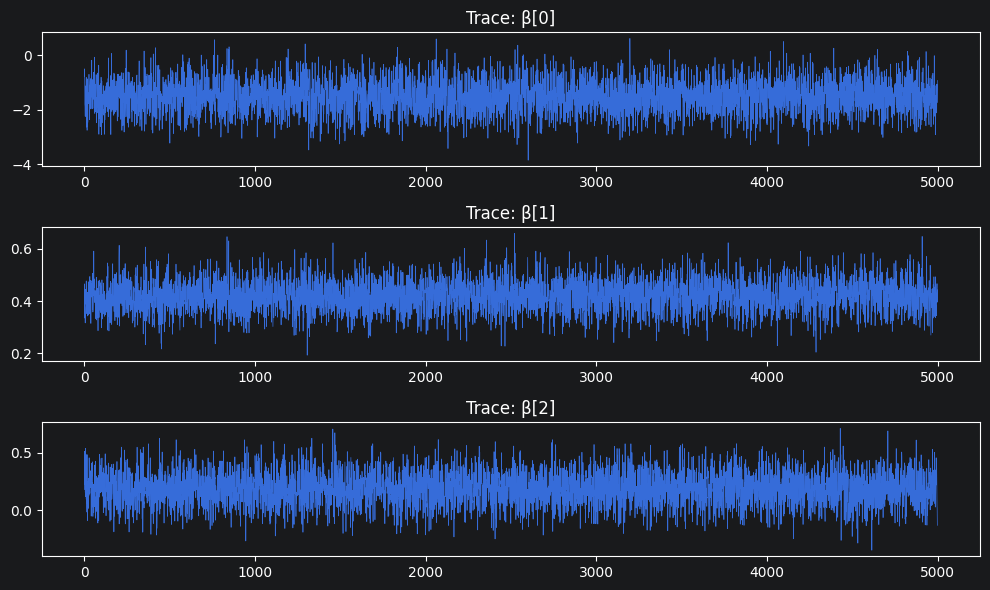

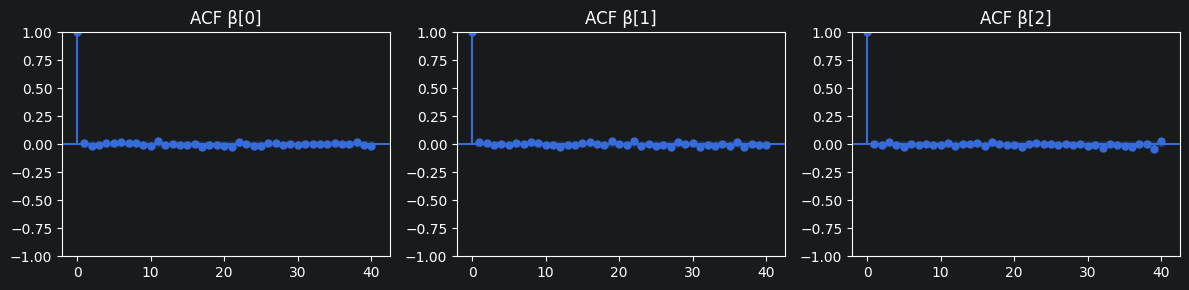

In [13]:
# Trace plot for first few beta coefficients
fig, axes = plt.subplots(3, 1, figsize=(10, 6))
for i, ax in enumerate(axes):
    ax.plot(beta_draws[:, i], lw=0.5)
    ax.set_title(f"Trace: β[{i}]")
plt.tight_layout()
plt.show()

# Autocorrelation of draws (visual inspection per Section 4.10.1)
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for i, ax in enumerate(axes):
    plot_acf(beta_draws[:, i], lags=40, ax=ax, title=f"ACF β[{i}]")
plt.tight_layout()
plt.show()

In [15]:
def bvar_forecast(X_new, beta_draws):
    """
    Generate 1-step ahead forecast by averaging over posterior draws.

    Parameters:
    - X_new: 1D array of shape (k,) containing [intercept, lag1_vars, lag2_vars]
    - beta_draws: 2D array of shape (n_draws, k * n) flattened beta matrices
    """
    preds = []
    n_vars = 4  # eui, gpr, cpu, oil_price
    k = X_new.shape[0]  # Should be 9 (1 intercept + 4 vars * 2 lags)

    for beta_flat in beta_draws:
        # Reshape the flat beta draw back into the (K x N) coefficient matrix
        # Note: Ensure the 'order' matches how you flattened it after PyMC sampling.
        # If you flattened standard PyMC output, order='C' (default) is usually safer,
        # but if your previous matrix math required 'F', keep it.
        B = beta_flat.reshape((k, n_vars), order='F')

        # Matrix multiplication: (1 x K) @ (K x N) = (1 x N) prediction
        preds.append(X_new @ B)

    return np.mean(preds, axis=0), np.std(preds, axis=0)

In [16]:
# -----------------------------
# BVAR Expanding Window Forecast
# -----------------------------

# Containers for results
bvar_preds = []
bvar_stds = []

# Convert full sample to numpy for fast indexing
# endog_full contains both train and test data sequentially
full_data_np = endog_full.values
n_train = len(train_df)
test_index = test_df.index

print(f"Running BVAR 1-step-ahead forecast for {len(test_index)} steps...")

for i in range(len(test_index)):
    # The absolute index in the full dataset for the current test point
    current_loc = n_train + i

    # Extract the actual historical data for lags 1 and 2
    # y[t-1] and y[t-2]
    lag1 = full_data_np[current_loc - 1]
    lag2 = full_data_np[current_loc - 2]

    # Construct the X vector for the current step
    # Matches shape: [Intercept(1.0), eui_t-1, gpr_t-1..., eui_t-2, gpr_t-2...]
    X_new = np.concatenate([[1.0], lag1, lag2])

    # Generate the predictive distribution for this step
    y_hat_mean, y_hat_std = bvar_forecast(X_new, beta_draws)

    # Extract ONLY the log_eui prediction (which is at index 0)
    bvar_preds.append(y_hat_mean[0])
    bvar_stds.append(y_hat_std[0])

# -----------------------------
# RMSE Calculation & Storage
# -----------------------------

# Convert to Pandas Series aligned with the test dates
bvar_forecast_series = pd.Series(bvar_preds, index=test_index, name="bvar_log_eui_forecast")

# Calculate the Out-of-Sample Errors
actual_log_eui_test = test_df.loc[test_index, "log_eui"]
bvar_resid_oos = (actual_log_eui_test - bvar_forecast_series).dropna()

# Calculate RMSE
rmse_freq = np.sqrt(np.mean(var_p2_resid_oos**2)) # From your previous Frequentist cell
rmse_bvar = np.sqrt(np.mean(bvar_resid_oos**2))

print("\n=== OOS PERFORMANCE COMPARISON ===")
print(f"Frequentist VAR(2) RMSE: {rmse_freq:.6f}")
print(f"Informed BVAR(2) RMSE:   {rmse_bvar:.6f}")

Running BVAR 1-step-ahead forecast for 67 steps...

=== OOS PERFORMANCE COMPARISON ===
Frequentist VAR(2) RMSE: 0.270232
Informed BVAR(2) RMSE:   0.265480
